In [16]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [17]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [18]:
from kszcnn.same_real_cnn_galaxy_positions import *

In [19]:
train_sets, test_sets = get_experiment_sets("same_real")
title = make_title("1P_0", input_type="position", exp_type="same_real")

In [20]:
print("SET:", set_name)
print("HALO_FILE:", HALO_FILE)

SET: 1P_0
HALO_FILE: /home/sucharita/kszCNN/data/groups_090_1P_0.hdf5


In [21]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [22]:
# load halos + subhalos
pos, vel, mass, sub_pos, sub_mstar = \
    load_groups_and_subhalos(HALO_FILE)

# build galaxy overdensity field 
density_grid = build_galaxy_density_grid(
    sub_pos,
    sub_mstar,
    Ngrid=128,
    mstar_cut=1e8
)

# smooth 
density_grid = smooth_delta_field(density_grid, SMOOTH_SCALE)

Selected galaxies: 923


In [23]:
#  5. Dataset 
rng = np.random.RandomState(SEED)
full_ds = HaloDatasetGalPos(pos, vel, mass, sub_pos,sub_mstar,
                      mass_cut=MASS_CUT, rng=rng)

#  split 
idxs = np.arange(len(full_ds))

train_idx, test_idx = train_test_split(
    idxs, test_size=0.2, random_state=SEED
)

train_idx, val_idx = train_test_split(
    train_idx, test_size=0.2, random_state=SEED
)

Selected halos: 547
Selected galaxies: 923


In [24]:
train_ds = Subset(full_ds, train_idx)
val_ds   = Subset(full_ds, val_idx)
test_ds  = Subset(full_ds, test_idx)

In [25]:
tr_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH)
te_loader  = DataLoader(test_ds, batch_size=BATCH)

In [26]:
#  9. Normalize velocity
y_train = np.array([full_ds[i][1] for i in train_idx])

y_mean = y_train.mean()
y_std  = y_train.std() + 1e-12

print("Velocity mean/std:", y_mean, y_std)

Velocity mean/std: 0.36430642 107.621216


In [27]:
# 6. Linear baseline (same realization)

# compute velocity field from FULL δg 
vlin_grid = compute_vlin_from_delta(
    density_grid,   # full box δg
    R_smooth=SMOOTH_SCALE
)

#  get test halos 
test_pos = full_ds.halo_pos[test_idx]
test_vz  = full_ds.vz[test_idx]

#  sample velocities at halo positions 
vlin_baseline = vlin_at_halos(
    vlin_grid,
    test_pos
)

#  correlation 
rho_vlin = pearsonr(test_vz, vlin_baseline)[0]

print("Linear theory correlation (δg):", rho_vlin)

Linear theory correlation (δg): 0.83614224


In [28]:
model = CNN().to(DEVICE)

In [29]:
train_model(
        model, tr_loader, val_loader, y_mean, y_std
    )

Epoch 1: Train=5.298e-01 | Val=7.896e-01
Epoch 2: Train=5.032e-01 | Val=7.987e-01
Epoch 3: Train=5.048e-01 | Val=7.646e-01
Epoch 4: Train=5.047e-01 | Val=7.669e-01
Epoch 5: Train=5.035e-01 | Val=7.756e-01
Epoch 6: Train=5.008e-01 | Val=7.701e-01
Epoch 7: Train=4.988e-01 | Val=7.580e-01
Epoch 8: Train=5.024e-01 | Val=7.896e-01
Epoch 9: Train=5.045e-01 | Val=7.815e-01
Epoch 10: Train=4.913e-01 | Val=7.447e-01
Epoch 11: Train=4.936e-01 | Val=7.443e-01
Epoch 12: Train=4.868e-01 | Val=8.679e-01
Epoch 13: Train=4.853e-01 | Val=7.383e-01
Epoch 14: Train=4.870e-01 | Val=7.325e-01
Epoch 15: Train=4.681e-01 | Val=7.890e-01
Epoch 16: Train=4.654e-01 | Val=7.228e-01
Epoch 17: Train=4.551e-01 | Val=6.467e-01
Epoch 18: Train=4.682e-01 | Val=7.712e-01
Epoch 19: Train=4.559e-01 | Val=6.494e-01
Epoch 20: Train=4.339e-01 | Val=6.222e-01
Epoch 21: Train=4.054e-01 | Val=5.449e-01
Epoch 22: Train=4.215e-01 | Val=6.105e-01
Epoch 23: Train=3.891e-01 | Val=6.043e-01
Epoch 24: Train=3.683e-01 | Val=5.192e-01
E

CNN(
  (conv): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): GroupNorm(8, 64, eps=1e-05, affine=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): GroupNorm(8, 128, eps=1e-05, affine=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

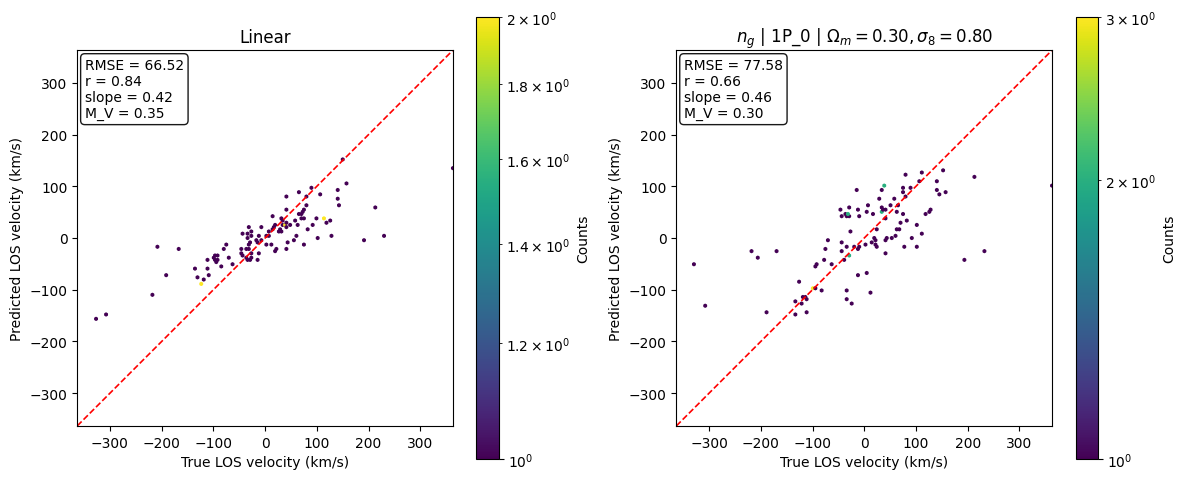

In [30]:
evaluate_model(
        model, te_loader, test_ds,
        y_mean, y_std,
        vlin_baseline, rho_vlin
    )